# Gaussian Processes

In [2]:
import numpy as np
import scipy as sp
import pandas as pd

In [76]:
import jax                                                     # JAX is designed for high-performance numerical computing
import jax.numpy as jnp                                        # The fast JAX variant of numpy arrays
jax.config.update("jax_enable_x64", True)                      # Enable double-precision computations

In [4]:
from tinygp import kernels, GaussianProcess                    # Our primary workhorse to model Gaussian Processes

In [78]:
import jaxopt                                                  # Function optimization library using JAX. Used to optimize the marginal log-likelihood.

In [153]:
import numpyro                                                 # Bayesian regression library relying on JAX. 
import numpyro.distributions as dist                           # Easy to install on Linux and OSX. Windows users: use WSL.
from numpyro.infer import MCMC, NUTS

In [268]:
import arviz as az                                             # For summarizing and plotting the MCMC traces

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
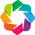

In [5]:
import holoviews as hv
hv.extension('bokeh')

## Exploring kernels with TinyGP

`TinyGP` doesn't have a lot of kernels, but [it has all the important ones](https://tinygp.readthedocs.io/en/latest/api/kernels.html), and you can define your own. Combining kernels and making your own kernel mixture by summing and multiplying existing kernels is very easy:

In [124]:
myKernel = kernels.ExpSquared(scale=1.5) + 2 * kernels.Matern32(scale=2.5)

Here `scale` is what we called _lengthscale_ in the slides.

You define a Gaussian Process $\mathcal{GP}(m(.), k(.,.))$ by providing a kernel $k()$ and a fixed set of function arguments $x$: 

In [125]:
x = np.linspace(0, 10, 100)
myGP = GaussianProcess(myKernel, x)

In principle you can also provide a mean function, but if you omit it, the GP will assume it's zero.

One thing you can do with a GP is draw random samples $(f(x_1), f(x_2), f(x_3), ..., f(x_n)) \sim \mathcal{N}(\mu, \Sigma)$ from it. This can be done using the `sample()` function which requires a random generator seed. It's important that you used a JAX seed by using `jax.random.PRNGKey()` function, don't simply insert your own integer number. 

In [126]:
# Draw 5 curves sampled from the GP

Ndraws = 5
y = myGP.sample(jax.random.PRNGKey(4), shape=(Ndraws,))

# Plot them on top of each other

plots = []
for idraw in range(Ndraws):
    df = pd.DataFrame.from_dict({'x': x, 'y': y[idraw, :]})
    plot = hv.Curve(df, 'x', 'y')
    plots.append(plot)
sample_curves = hv.Overlay(plots)
sample_curves.opts(width=400, xlim=(0,10))

# Compute the covariance matrix of the GP

covmatrix = hv.Image(np.array(myKernel(x,x)), bounds=(0,0,x[-1],x[-1]))             # left, bottom, right, top
covmatrix.opts(width=300, cmap='Viridis')

# Plot the samples and the covariance matrix next to each other

myplot = sample_curves + covmatrix
myplot.opts(shared_axes=False)

:Layout
   .Overlay.I :Overlay
      .Curve.I   :Curve   [x]   (y)
      .Curve.II  :Curve   [x]   (y)
      .Curve.III :Curve   [x]   (y)
      .Curve.IV  :Curve   [x]   (y)
      .Curve.V   :Curve   [x]   (y)
   .Image.I   :Image   [x,y]   (z)

## A simple example on how to set up a Gaussian Process with TinyGP

#### Create a synthetic dataset

The data is generated using
$$ y_n = \frac{\sin x_n}{x_n} + \varepsilon_n $$
where $\varepsilon \sim \mathcal{N}(\mu=0, \sigma=0.05)$

In [365]:
rng = np.random.default_rng(1235)
train_x = np.linspace(0.1, 10, 20)
train_y = np.sin(train_x) / train_x + rng.normal(0.0, 0.05, len(train_x)) 

In [366]:
df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(toolbar='above', fontscale=1.3, width=500, height=350, xlabel='x', ylabel='y', show_grid=True, size=7)

:Scatter   [x]   (y)

#### Set up the TinyGp model

We want to set up a GP with a squared exponential covariance function:
$$ k(x_n, x_m) = a^2 \exp\left(-\frac{1}{2\lambda^2}|x_n - x_m|^2\right) $$
which depends on two parameters: the amplitude $a$ and the lengthscale $\lambda$. In addition we have measurement noise which we take into account by adding a variance $\sigma^2$ to the diagonal of the covariance matrix:
$$ \Sigma = K(x,x) + \sigma^2 I$$
We aim to fit the GP to our dataset and determine the most optimal values for $a^2$, $\lambda$ and $\sigma^2$.

The typical workflow with TinyGP consists of only a few steps. The first one is that you define a function that builds the GP. I.e. a function that sets up the covariance kernel and the mean function (zero in this example), and returns a Gaussian Process. For numerical reasons we won't be fitting $a^2$, $\lambda$ and $\sigma^2$ directly, but rather $\theta_0 = \ln a^2$, $\theta_1 = \ln\lambda$ and $\theta_2 = \ln\sigma^2$, and then take $a^2=e^{\theta_0}$, $\lambda=e^{\theta_1}$ and $\sigma^2=e^{\theta_2}$. The advantage is that this way we can guarantee that $a^2$, $\lambda$ and $\sigma^2$ are always positive, no matter how the fitting process goes.   

It's important that within the build function you don't use Numpy functions like `np.exp()`, but rather the equivalent optimized functions of JAX, like `jnp.exp()`.  

In [367]:
def build_GP(theta, x):
    amplitude_sq = jnp.exp(theta["log_amplitude_sq"])
    lengthscale  = jnp.exp(theta["log_lengthscale"])
    myKernel = amplitude_sq * kernels.ExpSquared(lengthscale)
    myGP = GaussianProcess(myKernel, x, diag=jnp.exp(theta["log_sigma_sq"]), mean=0.0)
    return myGP

In a second step we define the marginal log-likelihood $\ln P(y | x)$ which will be used as a cost function to fit and to determine the model parameters $a$, $\lambda$ and $\sigma^2$. It's important that you _decorate_ this function with `@jax.jit`. This decorator provides derivatives to our function in a clever way, and these derivatives will be used later on to optimize this function. 

At first, this function seems highly inefficient: why is the building of the GP happen inside the function? Why not simply give the GP as an argument to the function so that it doesn't need to be re-build every time you call this function? Don't worry, the `@jax.jit` decorator is clever enough to recognize this, and remove any redundant builds.

In [368]:
@jax.jit
def neg_marginal_log_likelihood(theta, x, y):
    myGP = build_GP(theta, x)
    return -myGP.log_probability(y)

#### Fit the GP to the data

The last step is to maximize $\ln P(y|x)$ which comes down to minimizing $-\ln P(y|x)$. We will be using the `jaxopt` library for this. The minimization routine requires initial values for the model parameters, which I usually estimate by looking at the plot of the dataset. Remember that we're not directly fitting $a$, $\lambda$ and $\sigma^2$ directly, but rather $\theta_0 = \ln a^2$, $\theta_1 = \ln\lambda$ and $\theta_2 = \ln\sigma^2$,  so we need to give initial values for the log's.

In [369]:
theta_init = {
    "log_sigma_sq":     np.log(0.1),
    "log_amplitude_sq": np.log(1.0),
    "log_lengthscale":  np.log(2.0)
}

In [370]:
solver = jaxopt.ScipyMinimize(fun=neg_marginal_log_likelihood)
solution = solver.run(theta_init, x=train_x, y=train_y)
if solution.state.success == True:
    print(f"Success after {solution.state.iter_num} iterations. Negative marginal log-likelihood = {solution.state.fun_val}")
else:
    print("No convergence.")

Success after 10 iterations. Negative marginal log-likelihood = -21.141902215182373


#### Plot the results

We now have optimal values $\widehat{a^2}$, $\hat{\lambda}$ and $\widehat{\sigma^2}$, so we build a GP with these specific values.

In [371]:
myGP = build_GP(solution.params, train_x)

Next we want to use the GP to make predictions $f(x^*)$ for some new function arguments $x^{*}$, which we call `test_x` in the code below. For this we need the conditional distribution
$$P(f(x^*)\ | \ f(x)=y)$$
where $x$ and $y$ are our original training set, which we called `train_x` and `train_y`. Once we have the conditional distribution we can derive its mean and the variance.

In [372]:
test_x = np.linspace(0, 15, 200)
conditionalGP = myGP.condition(train_y, test_x).gp
mean, variance = conditionalGP.loc, conditionalGP.variance

It's always useful to plot some sample of the conditional GP on top of your data, as a sanity check that your fitting converged properly.

In [373]:
Nsamples = 40
samples = conditionalGP.sample(jax.random.PRNGKey(926354), shape=(Nsamples,))

Now we can easily make all the plots:

In [374]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=6)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x, 'y': mean})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

# Some samples

plots = [scatter, curve]
for isample in range(Nsamples):
    df = pd.DataFrame.from_dict({'x': test_x, 'y': samples[isample, :]})
    plot = hv.Curve(df, 'x', 'y')
    plot.opts(color="gray", alpha=0.1)
    plots.append(plot)

# Plot everything combined

myplot = hv.Overlay(plots)
myplot.opts(width=600, height=400, show_grid=True, xlim=(0,15), fontscale=1.4)
 

:Overlay
   .Scatter.I     :Scatter   [x]   (y)
   .Curve.I       :Curve   [x]   (y)
   .Curve.II      :Curve   [x]   (y)
   .Curve.III     :Curve   [x]   (y)
   .Curve.IV      :Curve   [x]   (y)
   .Curve.V       :Curve   [x]   (y)
   .Curve.VI      :Curve   [x]   (y)
   .Curve.VII     :Curve   [x]   (y)
   .Curve.VIII    :Curve   [x]   (y)
   .Curve.IX      :Curve   [x]   (y)
   .Curve.X       :Curve   [x]   (y)
   .Curve.XI      :Curve   [x]   (y)
   .Curve.XII     :Curve   [x]   (y)
   .Curve.XIII    :Curve   [x]   (y)
   .Curve.XIV     :Curve   [x]   (y)
   .Curve.XV      :Curve   [x]   (y)
   .Curve.XVI     :Curve   [x]   (y)
   .Curve.XVII    :Curve   [x]   (y)
   .Curve.XVIII   :Curve   [x]   (y)
   .Curve.XIX     :Curve   [x]   (y)
   .Curve.XX      :Curve   [x]   (y)
   .Curve.XXI     :Curve   [x]   (y)
   .Curve.XXII    :Curve   [x]   (y)
   .Curve.XXIII   :Curve   [x]   (y)
   .Curve.XXIV    :Curve   [x]   (y)
   .Curve.XXV     :Curve   [x]   (y)
   .Curve.XXVI    :Curve   [x]   (y)
   .Curve.XXVII   :Curve   [x]   (y)
   .Curve.XXVIII  :Curve   [x]   (y)
   .Curve.XXIX    :Curve   [x]   (y)
   .Curve.XXX     :Curve   [x]   (y)
   .Curve.XXXI    :Curve   [x]   (y)
   .Curve.XXXII   :Curve   [x]   (y)
   .Curve.XXXIII  :Curve   [x]   (y)
   .Curve.XXXIV   :Curve   [x]   (y)
   .Curve.XXXV    :Curve   [x]   (y)
   .Curve.XXXVI   :Curve   [x]   (y)
   .Curve.XXXVII  :Curve   [x]   (y)
   .Curve.XXXVIII :Curve   [x]   (y)
   .Curve.XXXIX   :Curve   [x]   (y)
   .Curve.XL      :Curve   [x]   (y)
   .Curve.XLI     :Curve   [x]   (y)

That's how easy it is to work with TinyGP!

In [375]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=6)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x, 'y': mean})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

# The 2-sigma uncertainty interval on the mean

sigma_low = mean - 2 * np.sqrt(variance)
sigma_up  = mean + 2 * np.sqrt(variance)
area = hv.Area((test_x, sigma_low, sigma_up), vdims=['sigma_low', 'sigma_up']) 
area.opts(color="blue", alpha=0.1)

plot = scatter * curve * area
plot.opts(toolbar='above', fontscale=1.3, width=600, height=400, xlim=(0,10), ylim=(-0.5,1.1), xlabel="x", ylabel="y", show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)
   .Area.I    :Area   [x]   (sigma_low,sigma_up)

---

## An example illustrating the impact of the length scale

#### Create a dataset

In [376]:
rng = np.random.default_rng(1334)

train_x = np.linspace(0, 1, 40)
ytrue = np.sin(2*np.pi*train_x) + np.sin(7*np.pi*train_x)
train_y = ytrue + rng.normal(0.0, 0.3, len(train_x)) 

In [377]:
df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(toolbar='above', fontscale=1.3, width=600, height=400, xlabel='x', ylabel='y', show_grid=True, size=5)

:Scatter   [x]   (y)

#### Training the GP with $\lambda=1$

Much of the code is very similar to the example above, so I refer to that example for more explanation.

In [378]:
def build_GP(theta, x):
    amplitude_sq   = jnp.exp(theta["log_amplitude_sq"])
    myKernel = amplitude_sq * kernels.ExpSquared(1.0)
    myGP = GaussianProcess(myKernel, x, diag=jnp.exp(theta["log_sigma_sq"]), mean=0.0)
    return myGP

@jax.jit
def neg_marginal_log_likelihood(theta, x, y):
    myGP = build_GP(theta, x)
    return -myGP.log_probability(y)

In [379]:
theta_init = {"log_sigma_sq": np.log(0.1), "log_amplitude_sq": np.log(1.0) }

solver = jaxopt.ScipyMinimize(fun=neg_marginal_log_likelihood)
solution = solver.run(theta_init, x=train_x, y=train_y)

In [380]:
test_x = np.linspace(0, 1, 200)
myGP = build_GP(solution.params, train_x)
conditionalGP = myGP.condition(train_y, test_x).gp
mean, variance = conditionalGP.loc, conditionalGP.variance

In [381]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=6)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x, 'y': mean})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

myplot = scatter * curve
myplot.opts(width=600, height=400, fontscale=1.3)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)

Clearly the lengthscale is too large. The GP only captures the global trend, and thinks all the other variability is due to noise.

#### Training the GP with $\lambda=0.003$

In [382]:
def build_GP(theta, x):
    amplitude_sq   = jnp.exp(theta["log_amplitude_sq"])
    myKernel = amplitude_sq * kernels.ExpSquared(0.003)
    myGP = GaussianProcess(myKernel, x, diag=jnp.exp(theta["log_sigma_sq"]), mean=0.0)
    return myGP

@jax.jit
def neg_marginal_log_likelihood(theta, x, y):
    myGP = build_GP(theta, x)
    return -myGP.log_probability(y)

In [383]:
theta_init = {"log_sigma_sq": np.log(0.1), "log_amplitude_sq": np.log(1.0) }

solver = jaxopt.ScipyMinimize(fun=neg_marginal_log_likelihood)
solution = solver.run(theta_init, x=train_x, y=train_y)

In [384]:
test_x = np.linspace(0, 1, 200)
myGP = build_GP(solution.params, train_x)
conditionalGP = myGP.condition(train_y, test_x).gp
mean, variance = conditionalGP.loc, conditionalGP.variance

In [385]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=6)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x, 'y': mean})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

myplot = scatter * curve
myplot.opts(width=600, height=400, fontscale=1.3)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)

Here the lengthscale is too small, and the GP is ov

#### Training the GP with $\lambda$ as a free parameter in a Bayesian framework

In the examples before we optimized the marginal log-likelihood to determine the model parameters. It's also possible to do a Bayesian modelling and determine the posterior distributions of our model parameters. The library `numpyro` is a Bayesian regression library that is build on JAX, and that is excellently suited to work with TinyGP. The following example illustrates how to use it.  

As usual, we have to specify priors for each of our model parameters:

In [386]:
test_x = np.linspace(0, 1, 200)

def myModel(x, y=None):

    # The priors
    
    lengthscale = numpyro.sample("lambda", dist.HalfNormal(3.0))
    sigma       = numpyro.sample("sigma", dist.HalfCauchy(2.0))
    amplitude   = numpyro.sample("ampl", dist.HalfNormal(5.0))

    # The Gaussian process
    
    kernel = amplitude**2 * kernels.ExpSquared(lengthscale)
    gp = GaussianProcess(kernel, x, diag=sigma**2, mean=0.0)
    numpyro.sample("gp", gp.numpyro_dist(), obs=y)

    # The mean of the predictive distribution
    
    if y is not None:
        numpyro.deterministic("pred", gp.condition(y, test_x).gp.loc)

`numpyro` features a NUTS sampler, so that's the one we will be using. The sampler required a random number generator seed. It's important that you use `jax.random.PRNGKey()` here rather than simply provide a random integer.

In [387]:
nuts_kernel = NUTS(myModel, dense_mass=True, target_accept_prob=0.9)
mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=3000, num_chains=4, progress_bar=True)
mcmc.run(jax.random.PRNGKey(34923), train_x, y=train_y)
samples = mcmc.get_samples()

/var/folders/nq/jk7wcz1x7p96_cv4lq5n9f1rdpknxw/T/ipykernel_81903/3450828824.py:2: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=1000, num_samples=3000, num_chains=4, progress_bar=True)
sample: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:02<00:00, 1648.92it/s, 7 steps of size 5.75e-01. acc. prob=0.95]


`Arviz` has a nice function that converts the output of `numpyro` to a trace object that it can use for further visualization.

In [388]:
data = az.from_numpyro(mcmc)
az.summary(data, var_names=[v for v in data.posterior.data_vars if v != "pred"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ampl,1.473,0.593,0.680,2.613,0.008,0.018,8651.0,5734.0,1.0
lambda,0.085,0.016,0.055,0.118,0.000,0.000,7303.0,6273.0,1.0
sigma,0.197,0.032,0.138,0.261,0.000,0.000,9731.0,7733.0,1.0


To plot the traces (always do this as sanity check), we use `Arviz` functionality:

In [389]:
traces = az.plot_trace(data, var_names=("ampl", "lambda", "sigma"), backend="bokeh", figsize=(16, 8))

In [390]:
pred = samples["pred"]
mean = np.mean(pred, axis=0)
stdev = np.std(pred, axis=0)
lower = mean - 2*stdev
upper = mean + 2*stdev

Now we are ready to make a plot of our solution:

In [391]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=6)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x, 'y': mean})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

# The 2-sigma uncertainty interval on the mean

area = hv.Area((test_x, lower, upper), vdims=['lower', 'upper']) 
area.opts(color="blue", alpha=0.2)

plot = scatter * curve * area
plot.opts(toolbar='above', fontscale=1.3, width=600, height=400, xlabel="x", ylabel="y", show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)
   .Area.I    :Area   [x]   (lower,upper)

The lengthscale $\lambda$ is clearly much better determined now.

---

## A worked-out example: the Mauna Loa dataset

The following dataset indicates why our planet risks to become uninhabitable if we do not act (very) fast:

In [392]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/CO2_MaunaLoa_monthly.csv"
data = pd.read_csv(url)
data.head()

,year,co2
0,1958.2027,315.70
1,1958.2877,317.45
2,1958.3699,317.51
3,1958.5370,315.86
4,1958.6219,314.93


In [395]:
scatter = hv.Scatter(data, 'year', 'co2')
scatter.opts(toolbar='above', fontscale=1.3, width=1000, height=500, 
             xlabel='year', ylabel='Monthly CO2 averages [ppm]', show_grid=True, size=2)

:Scatter   [year]   (co2)

### Gaussian process setup

In [396]:
train_x = data['year'].values
train_y = data['co2'].values

To model this dataset we will use a mixture of kernels.

For the longterm (increasing trend) we won't use a linear or even polynomial trend, but simply assume that it varies smoothly enough so that we can use a squared exponential kernel:
$$ k_1(x_n, x_m) = a_1^2 \exp\left(-\frac{|x_n - x_m|^2}{2\lambda_1^2}\right) $$
Here $a_1$ is the amplitude of the variations, and $\lambda_1$ is the lengthscale after which two points become more and more uncorrelated.
For the seasonal (yearly) variations we need a kernel that is periodic. TinyGP features the so-called _exponential sine squared_, sometimes also called the _quasiperiodic kernel_:
$$ k(x_n, x_m) = a_2^2 \exp\left(-\Gamma \cdot \sin^2\left(\pi\frac{|x_n - x_m|}{P}\right)\right) $$
Here $a_2$ is an amplitude, $P$ is the period (around 1 yr for our dataset), and $\Gamma$ is an inverse lengthscale. We won't be using the quasiperiodic kernel directly but rather multiply it with a squared exponential kernel so that we can account for possible drifts in the periodic behaviour of the signal:
$$ k_2(x_n, x_m) = a_2^2 \exp\left(-\frac{|x_n - x_m|^2}{2\lambda_2^2}\right) \ \exp\left(-\Gamma \cdot \sin^2\left(\pi\frac{|x_n - x_m|}{P}\right)\right) $$
To understand the impact of the different parameters $\lambda_2$, $P$ and $\gamma$, we plot typical covariance matrices for different values of these parameters:

In [397]:
x = np.linspace(0,15,100)
kernel1 = kernels.ExpSquared(scale=7)
kernel2 = kernels.ExpSineSquared(scale=3, gamma=0.5)
kernel3 = kernels.ExpSineSquared(scale=3, gamma=2)
kernel4 = kernels.ExpSineSquared(scale=5, gamma=2)
combined = kernel1 * kernel2

covmatrix1 = hv.Image(np.array(kernel2(x,x)), bounds=(0,0,x[-1],x[-1]))             # left, bottom, right, top
covmatrix1.opts(width=300, height=300, cmap='Viridis', title="Period=3, gamma=0.5")

covmatrix2 = hv.Image(np.array(kernel3(x,x)), bounds=(0,0,x[-1],x[-1]))             # left, bottom, right, top
covmatrix2.opts(width=300, height=300, cmap='Viridis', title="Period=3, gamma=2")

covmatrix3 = hv.Image(np.array(kernel4(x,x)), bounds=(0,0,x[-1],x[-1]))             # left, bottom, right, top
covmatrix3.opts(width=300, height=300, cmap='Viridis', title="Period=5, gamma=2")

covmatrix4 = hv.Image(np.array(combined(x,x)), bounds=(0,0,x[-1],x[-1]))             # left, bottom, right, top
covmatrix4.opts(width=300, height=300, cmap='Viridis', title="ExpSineSquared * ExpSquared")

myplot = covmatrix1 + covmatrix2 + covmatrix3 + covmatrix4
myplot

:Layout
   .Image.I   :Image   [x,y]   (z)
   .Image.II  :Image   [x,y]   (z)
   .Image.III :Image   [x,y]   (z)
   .Image.IV  :Image   [x,y]   (z)

The first three images are all for the quasiperiodic covariance function. The period $P$ introduces strong correlation at periodic distances between two points. The parameter $\gamma$ determines how low correlation is at lengths that are not exactly a multiple of the period P. Finally, the last covariance matrix shows when you multiply as squared-exponential kernel with a quasiperiodic kernel. The squared-exponential kernel causes the strong periodic correlation to only hold for a few periods after which it slowly decays. This allows us to model a periodic variability where we are not sure if the periodicity is very strict in time. 

Looking at the data, disregarding the long-term trend, we notice that the variation is not strictly periodic, there are small differences from season to season. To model these medium-term variations we will use the _rational quadratic kernel_:
$$ k_3(x_n, x_m) = a_3^2 \cdot \left(1+\frac{(x_n - x_m)^2}{2\alpha\lambda_3}\right)^{-\alpha}$$
Why not the squared exponential kernel? Because experimenting revealed that the RQ kernel works better, probably because it is able to work on different lengthscales simultaneously, where the SE only works on one lengthscale $\lambda$. The scale mixture parameter $\alpha$ configures the relative weighting of short and long lengthscales. For $\alpha\rightarrow\infty$ the RQ kernel behaves like a SE kernel varying on a single lengthscale $\lambda$. 

Finally, we also want to model the very-short term changes, for example caused by a local short-term weather phenomenon. To do this, we will use again a squared-exponential kernel:
$$ k_4(x_n, x_m) = a_4^2 \cdot \exp\left(-\frac{|x_n - x_m|^2}{2\lambda_4^2}\right) $$

How does the Gaussian process know that $k_1$ is meant to have a long lengthscale $\lambda_1$ and that $k_4$ is meant to have a short lengthscale $\lambda_4$? It doesn't, but what we hope is that one of the two converges to a long scale, and the other to a short scale. We don't really care which one converges to what. 

Our final kernel is simply the sum of all 4 kernels above:
$$ k(x_n, x_m) = k_1(x_n, x_m) + k_2(x_n, x_m) + k_3(x_n, x_m) + k_4(x_n, x_m) $$

As before we always model $\ln\lambda$ of a model parameter $\lambda$ to ensure that $\lambda$ itself is guaranteed to be positive.

In [398]:
def build_GP(theta, x):
    amplitudes_sq = jnp.exp(theta["log_amplitudes_sq"])                       # Amplitudes
    lengthscales  = jnp.exp(theta["log_lengthscales"])                        # Lengthscales

    k1 = amplitudes_sq[0] * kernels.ExpSquared(lengthscales[0])
    k2 = amplitudes_sq[1] * kernels.ExpSquared(lengthscales[1]) * kernels.ExpSineSquared(scale=jnp.exp(theta["log_period"]), gamma=jnp.exp(theta["log_gamma"]))
    k3 = amplitudes_sq[2] * kernels.RationalQuadratic(alpha=jnp.exp(theta["log_alpha"]), scale=lengthscales[2] )
    k4 = amplitudes_sq[3] * kernels.ExpSquared(lengthscales[3])
    kernel = k1 + k2 + k3 + k4

    return GaussianProcess(kernel, x, diag=jnp.exp(theta["log_sigma_sq"]), mean=theta["mean"] )



@jax.jit
def neg_marginal_log_likelihood(theta, x, y):
    gp = build_GP(theta, x)
    return -gp.log_probability(y)

We optimize the GP by minimizing the negative marginal log-likelihood. This particular dataset and the fairly complex GP is in fact not that easy to fit. When you don't choose reasonable initial values for the different parameters, the minimizer often doesn't converge. This is not a particular problem of TinyGP, it's also the case with other libraries such as `GPyTorch` and `PyMC`, the problem is simply rather challenging. When facing problems with the fitting you should first try different initial values, and if that does not help, try a different minimizer: `JaxOpt` has several options.   

In [399]:
theta_init = {
    "mean":              np.float64(340.0),
    "log_sigma_sq":      np.log(0.19),
    "log_amplitudes_sq": np.log([66.0, 2.4, 0.66, 0.18]),
    "log_lengthscales":  np.log([67.0, 90.0, 0.78, 1.6]),
    "log_period":        np.float64(0.0),
    "log_gamma":         np.log(4.3),
    "log_alpha":         np.log(1.2),
}

solver = jaxopt.ScipyMinimize(fun=neg_marginal_log_likelihood)
solution = solver.run(theta_init, x=train_x, y=train_y)
print(f"Final negative marginal log likelihood: {solution.state.fun_val}")

Final negative marginal log likelihood: 193.55863473932862


When plotting the optimal model parameters, don't forget to take the exponential again. Also, the scale factor in front of each kernel is amplitude squared, not amplitude, and it's the amplitude that has the unit [ppm].

In [401]:
print('Long-term trend:')
print('    amplitude:    ', np.sqrt(np.exp(solution.params['log_amplitudes_sq'][0])), "ppm")
print('    lengthscale:  ', np.exp(solution.params['log_lengthscales'][0]), "yr")
print('Seasonal component:')
print('    amplitude:    ', np.sqrt(np.exp(solution.params['log_amplitudes_sq'][1])), "ppm")
print('    period:       ', np.exp(solution.params['log_period']), "yr")
print('    decay length: ', np.exp(solution.params['log_lengthscales'][1]), "yr")
print('    gamma:        ', np.exp(solution.params['log_gamma']))
print('Mid-term component:')
print('    amplitude:    ', np.sqrt(np.exp(solution.params['log_amplitudes_sq'][2])), "ppm")
print('    lengthscale:  ', np.exp(solution.params['log_lengthscales'][2]), "yr")
print('    alpha:        ', np.exp(solution.params['log_alpha']))
print('Short-term component:')
print('    amplitude:    ', np.sqrt(np.exp(solution.params['log_amplitudes_sq'][3])), "ppm")
print('    lengthscale:  ', np.exp(solution.params['log_lengthscales'][3]), "yr")
print('Measurement noise:')
print('     sigma:       ', np.sqrt(np.exp(solution.params['log_sigma_sq'])), "ppm")

Long-term trend:
    amplitude:     296.1308309896473 ppm
    lengthscale:   148.23572554945062 yr
Seasonal component:
    amplitude:     2.4167189703821275 ppm
    period:        0.9998823306203742 yr
    decay length:  143.77606044858132 yr
    gamma:         1.2649699368768326
Mid-term component:
    amplitude:     19.13479455910833 ppm
    lengthscale:   11.830862737895586 yr
    alpha:         0.0001023257289667935
Short-term component:
    amplitude:     1.5657816151241597e-05 ppm
    lengthscale:   0.009580977682771339 yr
Measurement noise:
     sigma:        0.20482932874541876 ppm


It seems that the GP could not find an appreciable short-term component: the amplitude is close to zero.

Build the conditional GP:

In [402]:
test_x = np.linspace(train_x.min(), train_x.max() + 10, 2000)
myGP = build_GP(solution.params, train_x)
conditionalGP = myGP.condition(train_y, test_x).gp
mean, variance = conditionalGP.loc, conditionalGP.variance

Plot our solution and its uncertainty on top of the data:

In [403]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x, 'y': train_y})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=5)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x, 'y': mean})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

# The 2-sigma uncertainty interval on the mean

sigma_low = mean - 2 * np.sqrt(variance)
sigma_up  = mean + 2 * np.sqrt(variance)
area = hv.Area((test_x, sigma_low, sigma_up), vdims=['sigma_low', 'sigma_up']) 
area.opts(color="blue", alpha=0.2)

plot = scatter * curve * area
plot.opts(toolbar='above', fontscale=1.3, width=900, height=500, xlim=(2015,2032), ylim=(390, 450),
          xlabel="year", ylabel="Monthly average CO2 [ppm]", show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)
   .Area.I    :Area   [x]   (sigma_low,sigma_up)

---